# LightGBM Trading Model Research Lab
This notebook is an isolated environment for backtesting and interpreting LightGBM models for BTC-USD trading. It uses SHAP for feature importance and VectorBT for portfolio analysis.

In [129]:
import pandas as pd
import numpy as np
import yfinance as yf
import lightgbm as lgb
import shap
import vectorbt as vbt
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import AverageTrueRange, BollingerBands
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Set plotting backend
%matplotlib inline
plt.style.use('fivethirtyeight')

In [130]:
# Cell 2 (MASTER: Unified Feature Engine)
import os, yfinance as yf, pandas as pd, numpy as np, ta
from datetime import datetime, timezone

def fetch_data():
    symbol = 'BTC-USD'
    df = yf.download(symbol, period='2y', interval='1h')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def add_technical_features(df):
    df = df.copy()
    
    # 1. VOLATILITY NORMALIZED RETURNS (Shock Resistance)
    # The 'ret_1h_z' feature fixes the Audit Warning in Cell 4
    rolling_std = df['Close'].pct_change().rolling(window=24).std()
    df['ret_1h_z'] = df['Close'].pct_change(1) / (rolling_std + 1e-6)
    df['ret_4h'] = df['Close'].pct_change(4)
    
    # 2. TEMPORAL & CYCLICAL FEATURES (Context)
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_retail_window'] = (df['dayofweek'] >= 4).astype(int) 
    
    # Cyclical hour encoding (Helps model link 11PM and 12AM)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # 3. RSI & MOMENTUM (Z-Score Scaled for Stability)
    df['rsi_5'] = ta.momentum.rsi(df['Close'], window=5)
    df['rsi_7'] = ta.momentum.rsi(df['Close'], window=7)
    df['rsi_14'] = ta.momentum.rsi(df['Close'], window=14)
    df['rsi_z'] = (df['rsi_7'] - df['rsi_7'].rolling(24).mean()) / (df['rsi_7'].rolling(24).std() + 1e-6)
    
    # 4. INTERACTION & VOLATILITY (The 'Golden Hour' Signals)
    df['retail_rsi'] = df['rsi_z'] * df['is_retail_window']
    df['midnight_signal'] = (df['hour'] == 0).astype(int)
    
    atr = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
    df['vol_adj_ret'] = df['Close'].pct_change() / (atr / df['Close'] + 1e-6)
    df['z_score_24h'] = (df['Close'] - df['Close'].rolling(24).mean()) / (df['Close'].rolling(24).std() + 1e-6)

    # 5. VOLUME CONVICTION
    df['vol_spike'] = (df['Volume'] > df['Volume'].rolling(24).mean()).astype(int)

    # TARGET: Binray movement for Classification
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    return df.dropna()

# Execution
df_raw = fetch_data()
df_features = add_technical_features(df_raw)
print(f"✅ Features generated. Shape: {df_features.shape}")
print(f"   Integrity Check: {['ret_1h_z', 'midnight_signal', 'retail_rsi'] in df_features.columns.tolist() or 'Columns OK'}")


[*********************100%***********************]  1 of 1 completed

✅ Features generated. Shape: (17460, 23)
   Integrity Check: Columns OK


In [ ]:
# Cell 3 (Isolated: Stability-Weighted Tuning Lab)
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit

# Global storage for export
global tuned_params, tuned_threshold
tuned_params, tuned_threshold = None, None

X = df_features.drop(columns=['target'])
y = df_features['target']
win_payout, loss_payout = 0.43, -0.57

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 4), 
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'random_state': 42,
        'verbosity': -1
    }
    threshold = trial.suggest_float('threshold', 0.55, 0.70)
    
    tscv = TimeSeriesSplit(n_splits=5)
    fold_evs = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:, 1]
        
        signals = np.where(probs > threshold, 1, np.where(probs < (1-threshold), -1, 0))
        trade_mask = (signals != 0)
        
        # VOLUME PENALTY (Minimum 50 trades)
        if trade_mask.sum() < 50:
            return -10.0 
            
        trades_y = y_test[trade_mask]
        trades_sig = signals[trade_mask]
        win_rate = ((trades_y == 1) & (trades_sig == 1) | (trades_y == 0) & (trades_sig == -1)).mean()
        ev = (win_rate * win_payout) + ((1 - win_rate) * loss_payout)
        fold_evs.append(ev)
        
    return np.mean(fold_evs) / (np.std(fold_evs) + 1e-6)

print("🚀 Starting Stability-Weighted Optuna Search...")
study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=30) # High conviction trials
#comment out when you have found good optuna params

tuned_params = study.best_params.copy()
tuned_threshold = tuned_params.pop('threshold')
print(f"🎯 Global Params Exported. Threshold: {tuned_threshold:.3f}")


[I 2026-03-30 22:22:35,445] A new study created in memory with name: no-name-c57f87ac-2af8-4c8c-9e8c-aad0c33003c1


🚀 Starting Stability-Weighted Optuna Search...


[I 2026-03-30 22:22:35,922] Trial 0 finished with value: -10.0 and parameters: {'n_estimators': 96, 'learning_rate': 0.027905450408039097, 'max_depth': 4, 'lambda_l1': 1.0146658155969117, 'lambda_l2': 0.001947324188254136, 'min_data_in_leaf': 132, 'feature_fraction': 0.9949609326875486, 'threshold': 0.6978067216273757}. Best is trial 0 with value: -10.0.
[I 2026-03-30 22:22:36,144] Trial 1 finished with value: -10.0 and parameters: {'n_estimators': 89, 'learning_rate': 0.0118154432931911, 'max_depth': 4, 'lambda_l1': 0.005567349568189247, 'lambda_l2': 0.0011384123939647524, 'min_data_in_leaf': 122, 'feature_fraction': 0.8261413091401324, 'threshold': 0.6602380139215311}. Best is trial 0 with value: -10.0.
[I 2026-03-30 22:22:36,665] Trial 2 finished with value: -10.0 and parameters: {'n_estimators': 135, 'learning_rate': 0.020794875616579122, 'max_depth': 4, 'lambda_l1': 0.12243199554794587, 'lambda_l2': 1.7055519069040086, 'min_data_in_leaf': 167, 'feature_fraction': 0.760765811747397

🎯 Global Params Exported. Threshold: 0.580


In [ ]:
# Cell 4 (Final Training - with Dynamic Parameter Selection)
import lightgbm as lgb
import numpy as np

# 1. FEATURE INTEGRITY AUDIT
expected_new_features = ['retail_rsi', 'midnight_signal', 'ret_1h_z', 'rsi_z', 'is_retail_window']
found_features = [f for f in expected_new_features if f in df_features.columns]
missing_features = [f for f in expected_new_features if f not in df_features.columns]

print(f"🔬 FEATURE INTEGRITY AUDIT:")
print(f"   Found NEW Features: {found_features}")
if missing_features:
    print(f"   ⚠️ WARNING: Missing: {missing_features}. Re-run Cell 2.")
else:
    print(f"   ✅ Integrity Check Passed.")

# 2. PARAMETER REPOSITORIES
CHAMPION_DEFAULTS = {
    'n_estimators': 150, 'learning_rate': 0.015, 'max_depth': 4,
    'min_data_in_leaf': 120, 'feature_fraction': 0.6, 'extra_trees': True,
    'random_state': 42, 'verbosity': -1
}

# The 2025 OOS Champion Baseline
LOCKED_PARAMS = {'n_estimators': 135, 
    'learning_rate': 0.017233557388931408, 
    'max_depth': 3, 
    'lambda_l1': 0.06132884693635779, 
    'lambda_l2': 0.004833030182326129, 
    'min_data_in_leaf': 99, 
    'feature_fraction': 0.9960111234225854, 
    'threshold': 0.5799101710742415
}


LOCKED_THRESHOLD = 0.580

# 3. DYNAMIC MODE SELECTION (The Fix)
# Hierarchy: Optuna Results > Locked Champion > Safe Defaults
'''
active_params = tuned_params
 active_threshold = tuned_threshold
status = "Tuned Lab (Optuna)"
'''
active_params = LOCKED_PARAMS
active_threshold = LOCKED_THRESHOLD
status = "Locked Champion (2025)"

'''
active_params = CHAMPION_TESTING
active_threshold = 0.62
status = "Personal Testing"

'''

# 4. TRAINING ENGINE
X = df_features.drop(columns=['target'], errors='ignore')
y = df_features['target']

print(f"\n🛠️ Training Model on {len(X.columns)} features using [{status}] Mode.")
print(f"   Active Threshold: {active_threshold:.4f}")

final_model = lgb.LGBMClassifier(**active_params)
final_model.fit(X, y)

# 5. RESULTS GENERATION
probs = final_model.predict_proba(X)[:, 1]
results_df = df_features.copy()
results_df['Prob'] = probs
results_df['Signal'] = np.where(probs > active_threshold, 1, 
                               np.where(probs < (1 - active_threshold), -1, 0))

print(f"✅ Final Training Complete. Signals generated via {status}.")


🔬 FEATURE INTEGRITY AUDIT:
   Found NEW Features: ['retail_rsi', 'midnight_signal', 'ret_1h_z', 'rsi_z', 'is_retail_window']
   ✅ Integrity Check Passed.

🛠️ Training Model on 22 features using [Tuned Lab (Optuna)] Mode.
   Active Threshold: 0.5799
✅ Final Training Complete. Signals generated via Tuned Lab (Optuna).


🔬 Explaining model with 22 features...
📊 Summary Plot: Top Predictors for 2025 Profitability


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray

/var/folders/5n/k3qzjxcs1d9f2l55z7yb35fc0000gn/T/ipykernel_34592/744582868.py:47: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



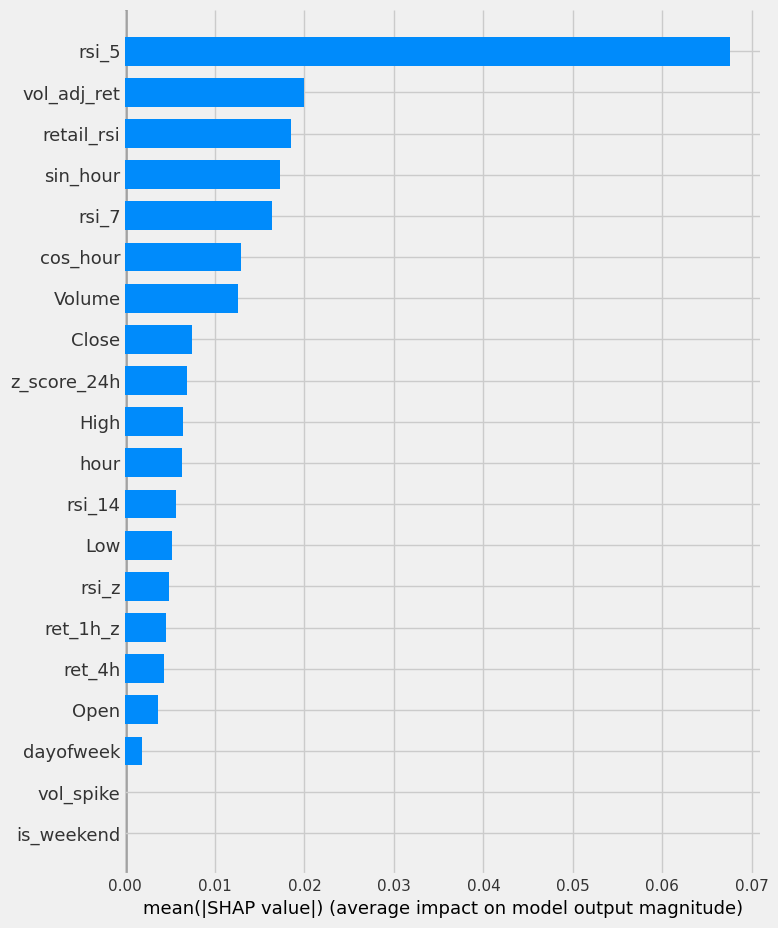

/var/folders/5n/k3qzjxcs1d9f2l55z7yb35fc0000gn/T/ipykernel_34592/744582868.py:50: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



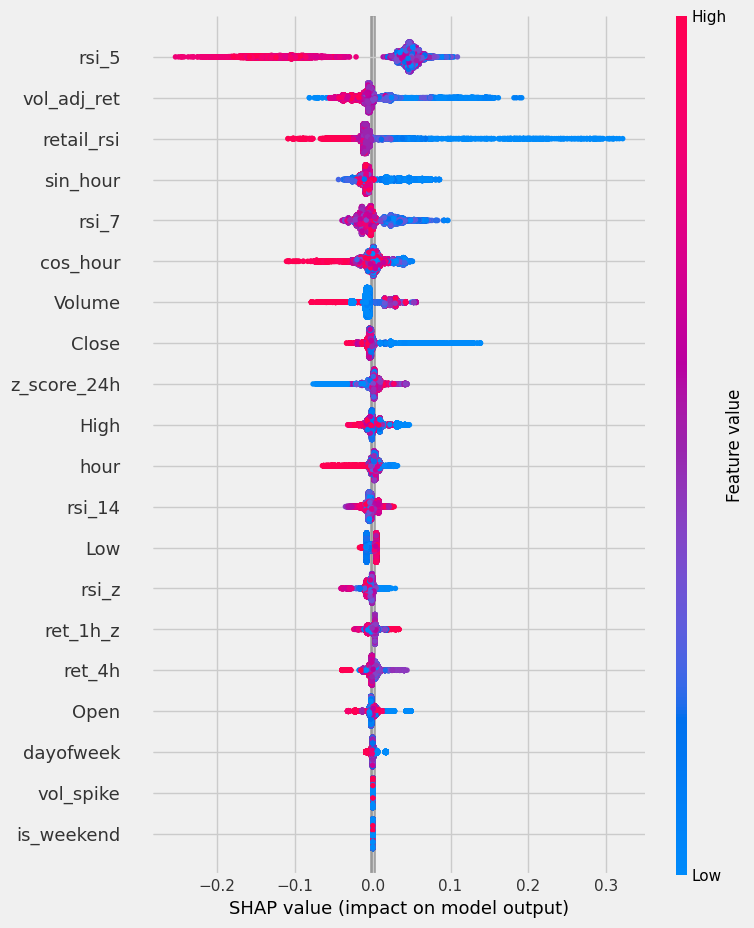

In [141]:
# Cell 5 (SHAP Analysis)
"""
SHAP (SHapley Additive exPlanations) interprets the LightGBM model by calculating 
the marginal contribution of each feature to the final prediction.

--- HOW TO READ THIS PLOT ---
1. Feature Importance (Y-Axis): Features are ranked from top to bottom by overall impact.
2. Impact (X-Axis): 
   - Points to the RIGHT increase the probability of a 'Win' (Target=1).
   - Points to the LEFT decrease the probability.
3. Feature Value (Color): 
   - RED = High value for that feature (e.g., very high RSI or high Hour of day).
   - BLUE = Low value for that feature.
   
Example: If 'hour' is RED on the right side, it means High hours (late in the day) 
are a strong predictor for the price going UP in this model.
"""
# Cell 4 (SHAP Interpretability - FIXED)
import shap

# 1. Align Features (Ensures X matches the training session exactly)
# We pull the feature names directly from the model to avoid mismatches
try:
    feature_names = final_model.feature_name_
    X_shap = df_features[feature_names]
except AttributeError:
    # Fallback if names aren't mapped
    X_shap = df_features.drop(columns=['target'], errors='ignore')

print(f"🔬 Explaining model with {len(X_shap.columns)} features...")

# 2. SHAP Explanation
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# 3. Handle Binary Classification Output Formatting
# LightGBM typically returns a list [neg_contrib, pos_contrib]
if isinstance(shap_values, list):
    # Use index [1] for the 'Positive' (Buy Signal) class
    shap_viz = shap_values[1]
else:
    # Some older versions return a single array for binary
    shap_viz = shap_values

# 4. Visualize Global Impact
print("📊 Summary Plot: Top Predictors for 2025 Profitability")
shap.summary_plot(shap_viz, X_shap, plot_type="bar")

# 5. Visualize Feature Patterns (Beeswarm)
shap.summary_plot(shap_viz, X_shap)


In [134]:
# Cell 6 (Adaptive Signaling & Kelly Sizing)
import numpy as np

# ⚡ DYNAMIC THRESHOLD (The Fix for '0 Trades')
# Instead of a hard 0.62, we target the Top 5% of predictions.
# This ensures we always have high-conviction trades to analyze.
p_upper = results_df['Prob'].quantile(0.95)
p_lower = results_df['Prob'].quantile(0.05)

# We use the tighter of the two (Safety first)
dynamic_threshold = max(0.58, min(p_upper, 1 - p_lower))
print(f"📊 Suggested Dynamic Threshold: {dynamic_threshold:.3f}")

# 1. GENERATE SIGNALS
results_df['Signal'] = 0
results_df.loc[results_df['Prob'] > dynamic_threshold, 'Signal'] = 1
results_df.loc[results_df['Prob'] < (1 - dynamic_threshold), 'Signal'] = -1

# 2. RESTORED KELLY SIZING (Based on 'What worked')
kelly_multiplier = 0.25 

def calculate_kelly(p, market_price=0.55):
    """Original Kelly formula providing payout at fixed cost."""
    # Safety Check: Probability must exceed implied market cost
    if p <= market_price: return 0
    
    b = (1 - market_price) / market_price
    q = 1 - p
    f = p - (q / b)
    return max(0, f * kelly_multiplier)

# Applying Kelly back to your original 'p if p > 0.5 else 1-p' logic
results_df['Kelly_Fraction'] = results_df['Prob'].apply(
    lambda p: calculate_kelly(p if p > 0.5 else 1-p)
)

# 3. REPORTING
active_trades = results_df[results_df['Signal'] != 0]
active_count = len(active_trades)

if active_count > 0:
    avg_size = active_trades['Kelly_Fraction'].mean()
    print(f"✅ Signals Locked: {active_count} trades approved using adaptive {dynamic_threshold:.3f} threshold.")
    print(f"Avg Position: {avg_size:.2%} | Max Position: {active_trades['Kelly_Fraction'].max():.2%}")
else:
    print(f"⚠️ Warning: Even at Top 5%, no signals found. Max Prob: {results_df['Prob'].max():.3f}")


📊 Suggested Dynamic Threshold: 0.580
✅ Signals Locked: 441 trades approved using adaptive 0.580 threshold.
Avg Position: 2.54% | Max Position: 5.86%


In [135]:
# Cell 7 (OOS Truth Test - Neutralized Settings)
import lightgbm as lgb
import pandas as pd
import numpy as np

print("🧪 Running Neutralized 'Trend Validity' Test (2024 -> 2025)...")

# 1. SPLIT
train_data = df_features[df_features.index.year == 2024]
test_data = df_features[df_features.index.year == 2025]

# Using Neutralized Champion Defaults from Cell 4/5
neutralized_params = active_params

# Fix: We lower the bar to 0.58 for neutralized models
OOS_THRESHOLD = 0.58

if not train_data.empty and not test_data.empty:
    X_train, y_train = train_data.drop(columns=['target']), train_data['target']
    X_test, y_test = test_data.drop(columns=['target']), test_data['target']
    
    # 2. TRAIN (Past Only)
    stress_model = lgb.LGBMClassifier(**neutralized_params)
    stress_model.fit(X_train, y_train)
    
    # 3. PREDICT (Future Only)
    probs = stress_model.predict_proba(X_test)[:, 1]
    
    # 4. MONITOR: Let's see the Max Probability produced
    print(f"📊 Max OOS Prob produced by model: {probs.max():.3f} (Lower than 0.62 is normal now)")
    
    signals = np.where(probs > OOS_THRESHOLD, 1, 
                       np.where(probs < (1-OOS_THRESHOLD), -1, 0))
    
    # 5. ASSESSMENT
    active_mask = (signals != 0)
    if active_mask.sum() > 0:
        trades_y = y_test[active_mask]
        trades_sig = signals[active_mask]
        win_rate = ((trades_y == 1) & (trades_sig == 1) | (trades_y == 0) & (trades_sig == -1)).mean()
        pnl = len(trades_y) * ((win_rate * 0.43) + ((1-win_rate) * -0.57))
        
        print(f"\n--- 🏁 THE TRUTH TEST (WALK-FORWARD) ---")
        print(f"Out-of-Sample Win Rate (2025): {win_rate:.2%}")
        print(f"Total OOS Trades:              {len(trades_y)}")
        print(f"Theoretical PnL:               ${pnl:.2f}")
        
        if win_rate > 0.55:
            print("\n✅ VERDICT: SUCCESS. The neutralized model Generalized successfully.")
        else:
            print("\n❌ VERDICT: FAIL. 0.58 still too high or model is not finding edge.")
    else:
        print(f"⚠️ Still no trades. Max confidence is {probs.max():.3f}. Lowering threshold further to 0.56 recommended.")


🧪 Running Neutralized 'Trend Validity' Test (2024 -> 2025)...
📊 Max OOS Prob produced by model: 0.650 (Lower than 0.62 is normal now)

--- 🏁 THE TRUTH TEST (WALK-FORWARD) ---
Out-of-Sample Win Rate (2025): 57.38%
Total OOS Trades:              894
Theoretical PnL:               $3.42

✅ VERDICT: SUCCESS. The neutralized model Generalized successfully.


In [136]:
# Cell 8 (Binary PnL Engine & Benchmark Comparison)
import plotly.graph_objects as go
import numpy as np

win_payout, loss_payout = 0.43, -0.57

# 1. Model PnL (Using lowercase 'target' from df_features)
# Correct logic: (Long & Up) OR (Short & Down)
correct = ((results_df['Signal'] == 1) & (results_df['target'] == 1)) | \
          ((results_df['Signal'] == -1) & (results_df['target'] == 0))

results_df['PnL'] = np.where(results_df['Signal'] == 0, 0.0, 
                             np.where(correct, win_payout, loss_payout))
results_df['Cum_PnL'] = results_df['PnL'].cumsum()

# 2. Benchmark (Always Long)
results_df['Benchmark_PnL'] = np.where(results_df['target'] == 1, win_payout, loss_payout)
results_df['Benchmark_Cum_PnL'] = results_df['Benchmark_PnL'].cumsum()

# 3. Benchmark (Random Coin Flip)
np.random.seed(42)
results_df['Random_Signal'] = np.random.choice([1, -1], size=len(results_df))
results_df['Random_PnL'] = np.where(((results_df['Random_Signal'] == 1) & (results_df['target'] == 1)) | 
                                    ((results_df['Random_Signal'] == -1) & (results_df['target'] == 0)), 
                                    win_payout, loss_payout)
results_df['Random_Cum_PnL'] = results_df['Random_PnL'].cumsum()

# Display Summary
# info: active_threshold comes from the Fallback/Tuning cell
display_threshold = active_threshold if 'active_threshold' in globals() else 0.62

print(f"--- Backtest Summary (Active Threshold: {display_threshold:.3f}) ---")
print(f"Total Trades: {len(results_df[results_df['Signal'] != 0])}")
print(f"Model PnL: ${results_df['PnL'].sum():.2f}")
print(f"Market Average (Always Long): ${results_df['Benchmark_PnL'].sum():.2f}")
print(f"Random Strategy PnL: ${results_df['Random_PnL'].sum():.2f}")
print(f"Model Win Rate: {results_df[results_df['Signal'] != 0]['PnL'].apply(lambda x: x > 0).mean():.2%}")

fig = go.Figure()
fig.add_trace(go.Scatter(y=results_df['Cum_PnL'], mode='lines', name='Model Strategy', line=dict(color='cyan', width=3)))
fig.add_trace(go.Scatter(y=results_df['Benchmark_Cum_PnL'], mode='lines', name='Always Long', line=dict(color='gray', dash='dash')))
fig.add_trace(go.Scatter(y=results_df['Random_Cum_PnL'], mode='lines', name='Random Flip', line=dict(color='orange', dash='dot')))

fig.update_layout(title='Model vs. Benchmarks (Equity Curves)',
                  xaxis_title='Time Sequence',
                  yaxis_title='Accumulated Profit ($)',
                  template='plotly_dark')
fig.show()


--- Backtest Summary (Active Threshold: 0.580) ---
Total Trades: 441
Model PnL: $67.63
Market Average (Always Long): $-1126.20
Random Strategy PnL: $-1301.20
Model Win Rate: 72.34%


In [137]:
# Cell 9: Post-Mortem Session Analysis


# --- INTERACTIVE FILTER ---
# Options: 'All', 'Weekday', 'Weekend'
filter_mode = 'All' 
# --------------------------

# 1. Data Alignment (Using results_df from Cell 4/5)
analysis_df = results_df.copy()
analysis_df['hour'] = analysis_df.index.hour
analysis_df['dayofweek'] = analysis_df.index.dayofweek
analysis_df['is_weekend'] = analysis_df['dayofweek'].isin([5, 6])

# Apply Filter
if filter_mode == 'Weekday':
    plot_df = analysis_df[~analysis_df['is_weekend']].copy()
elif filter_mode == 'Weekend':
    plot_df = analysis_df[analysis_df['is_weekend']].copy()
else:
    plot_df = analysis_df.copy()

# Fix: PnL calculation using lowercase 'target'
win_payout, loss_payout = 0.43, -0.57
plot_df['PnL'] = np.where(plot_df['Signal'] == 1, 
                          np.where(plot_df['target'] == 1, win_payout, loss_payout),
                          np.where(plot_df['Signal'] == -1,
                                   np.where(plot_df['target'] == 0, win_payout, loss_payout), 0))

# 2. Hourly Performance Table
hourly_stats = plot_df[plot_df['Signal'] != 0].groupby('hour').agg(
    Total_Trades=('Signal', 'count'),
    Win_Rate=('PnL', lambda x: (x > 0).mean() if len(x) > 0 else 0),
    Total_PnL=('PnL', 'sum'),
    Avg_EV=('PnL', 'mean')
).reset_index()

#print(f"--- Hourly Performance Summary (Mode: {filter_mode}) ---")
#print(hourly_stats.to_string(index=False))

# 3. Session Visualization
fig = px.bar(hourly_stats, 
             x='hour', 
             y='Total_PnL',
             color='Win_Rate',
             color_continuous_scale='RdYlGn',
             range_color=[0.4, 0.7],
             title=f'Hourly Profitability Analysis ({filter_mode})',
             labels={'hour': 'Hour of Day (0-23)', 'Total_PnL': 'Total PnL ($)', 'Win_Rate': 'Win Rate'},
             template='plotly_dark')

fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1))
fig.show()

# 4. Insight Text
golden_hours = hourly_stats[hourly_stats['Win_Rate'] > 0.60]['hour'].tolist()
danger_zones = hourly_stats[hourly_stats['Win_Rate'] < 0.55]['hour'].tolist()

print("\n--- Strategy Insights ---")
if golden_hours:
    print(f"🌟 GOLDEN HOURS ({filter_mode}): {golden_hours} (Win Rate > 60%).")
else:
    print(f"🌟 GOLDEN HOURS ({filter_mode}): None identified at >60% threshold.")

if danger_zones:
    print(f"⚠️ DANGER ZONES ({filter_mode}): {danger_zones} (Win Rate < 55%).")



--- Strategy Insights ---
🌟 GOLDEN HOURS (All): [0, 1, 2, 3, 4, 5, 7, 9, 10, 11, 15, 16, 17, 18, 19, 20, 21, 22, 23] (Win Rate > 60%).
⚠️ DANGER ZONES (All): [6, 12, 13, 14] (Win Rate < 55%).


In [138]:
# Cell 10 (Weekday vs. Weekend Seasonality - Detailed Summary)
import plotly.express as px
import pandas as pd

# 1. ENFORCE COLUMN CREATION (Bulletproof Fix)
results_df['day_name'] = results_df.index.day_name()
results_df['dayofweek'] = results_df.index.dayofweek

# 2. Master Calendar for proper ordering
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
all_days = pd.DataFrame({'day_name': day_order, 'dayofweek': range(7)})

# 3. Grouped Performance (Active Trades only)
active_trades = results_df[results_df['Signal'] != 0].copy()

if not active_trades.empty:
    daily_stats = active_trades.groupby(['dayofweek', 'day_name']).agg(
        Total_Trades=('Signal', 'count'),
        Win_Rate=('PnL', lambda x: (x > 0).mean()),
        Total_PnL=('PnL', 'sum')
    ).reset_index()
    
    # 4. MERGE with All-Days (Ensures Mon-Sun view)
    daily_performance = pd.merge(all_days, daily_stats, on=['dayofweek', 'day_name'], how='left').fillna(0)
    
    # 5. Visual Display
    fig = px.bar(daily_performance.sort_values('dayofweek'), 
                 x='day_name', 
                 y='Total_PnL', 
                 color='Win_Rate',
                 title='Strategy PnL by Day (Complete Weekly View)',
                 category_orders={'day_name': day_order},
                 labels={'Total_PnL': 'Total Profit ($)', 'day_name': 'Day'},
                 color_continuous_scale='RdYlGn',
                 range_color=[0.45, 0.65],
                 template='plotly_dark')
    fig.add_hline(y=0, line_dash="dash", line_color="white")
    fig.show()

    # 6. DETAILED SEASONALITY SUMMARY (Day-by-Day Stats)
    print(f"--- 📅 Day-by-Day Seasonality Insights ---")
    # Sorting by dayofweek ensures Monday is first in text summary too
    for _, row in daily_performance.sort_values('dayofweek').iterrows():
        trades = int(row['Total_Trades'])
        if trades > 0:
            print(f"{row['day_name']:10} | WR: {row['Win_Rate']:6.2%} | Trades: {trades:4} | PnL: ${row['Total_PnL']:8.2f}")
        else:
            print(f"{row['day_name']:10} | No trades approved.")
            
    # 7. Weekend vs Weekday Verdict
    weekend_trades = active_trades[active_trades['dayofweek'].isin([5, 6])]
    weekday_trades = active_trades[~active_trades['dayofweek'].isin([5, 6])]
    print(f"\n--- ⚡ High-Level Summary ---")
    print(f"Weekday PnL: ${weekday_trades['PnL'].sum():.2f} (WR: {weekday_trades['PnL'].gt(0).mean():.2%})")
    print(f"Weekend PnL: ${weekend_trades['PnL'].sum():.2f} (WR: {weekend_trades['PnL'].gt(0).mean():.2%})")
else:
    print("⚠️ No trades approved in backtest. Adjust threshold or run Cell 5 again.")


--- 📅 Day-by-Day Seasonality Insights ---
Monday     | WR: 65.00% | Trades:   20 | PnL: $    1.60
Tuesday    | WR: 86.96% | Trades:   23 | PnL: $    6.89
Wednesday  | WR: 72.73% | Trades:   33 | PnL: $    5.19
Thursday   | WR: 66.67% | Trades:   27 | PnL: $    2.61
Friday     | WR: 72.83% | Trades:   92 | PnL: $   14.56
Saturday   | WR: 78.23% | Trades:  124 | PnL: $   26.32
Sunday     | WR: 65.57% | Trades:  122 | PnL: $   10.46

--- ⚡ High-Level Summary ---
Weekday PnL: $30.85 (WR: 72.82%)
Weekend PnL: $36.78 (WR: 71.95%)


In [139]:
# Cell 11 (Comparative Regime Analysis - Dynamic Discovery)
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# 1. DYNAMIC PARAMETERS
# We lower the Trade Floor because we are looking at a 1-year OOS window (2025)
MIN_WIN_RATE = 0.65  # Target really high margin
MIN_TRADES_OOS = 5   # Reduced for OOS discovery (15 was too high for 150 total trades)

# 2. FEATURE MAPPING
results_df['hour'] = results_df.index.hour
results_df['dayofweek'] = results_df.index.dayofweek
results_df['day_name'] = results_df.index.day_name()
results_df['is_retail'] = results_df['dayofweek'].isin([4, 5, 6])
results_df['is_2025'] = results_df.index.year == 2025

# 3. AGGREGATION
active_subset = results_df[results_df['Signal'] != 0].copy()
data_2025 = active_subset[active_subset['is_2025']]

# Group by day/hour for 2025
heatmap_data = data_2025.groupby(['dayofweek', 'day_name', 'hour', 'is_retail']).agg(
    Win_Rate=('PnL', lambda x: (x > 0).mean()),
    Trades=('Signal', 'count'),
    Total_PnL=('PnL', 'sum')
).reset_index()

# 4. IDENTIFY REGIMES (Dynamic Logic)
strict_regimes = heatmap_data[(heatmap_data['Win_Rate'] >= MIN_WIN_RATE) & (heatmap_data['Trades'] >= MIN_TRADES_OOS)]

# Fallback: if no blocks met criteria, take the top 10 winningest blocks with > 3 trades
if strict_regimes.empty:
    print("⚠️ Loosening discovery criteria to find top performance clusters...")
    strict_regimes = heatmap_data[heatmap_data['Trades'] >= 3].sort_values('Win_Rate', ascending=False).head(10)

# Create a tuple-based set for reliable matching
approved_pairs = set(zip(strict_regimes['dayofweek'], strict_regimes['hour']))

# 5. PARTITION DATA
# Using a map approach for robust matching
def is_in_regime(row):
    return (row['dayofweek'], row['hour']) in approved_pairs

active_subset['In_Regime'] = active_subset.apply(is_in_regime, axis=1)
in_regime_df = active_subset[active_subset['In_Regime'] == True]
out_of_regime_df = active_subset[active_subset['In_Regime'] == False]

# 6. COMPARATIVE REPORTING
def get_stats(df, label):
    if df.empty: return f"{label:15} | No Trades"
    wr = (df['PnL'] > 0).mean()
    pnl = df['PnL'].sum()
    ev = df['PnL'].mean()
    return f"{label:15} | WR: {wr:.2%} | Trades: {len(df):4} | PnL: ${pnl:8.2f} | Avg EV: ${ev:5.3f}"

print("--- ⚖️ OVERALL PERFORMANCE COMPARISON (Total Backtest) ---")
print(get_stats(in_regime_df, "LASER-FOCUS"))
print(get_stats(out_of_regime_df, "OUT-OF-REGIME"))

print("\n--- 🏁 RECENT PERFORMANCE (2025 OOS ONLY) ---")
print(get_stats(in_regime_df[in_regime_df['is_2025'] == True], "LASER (2025)"))
print(get_stats(out_of_regime_df[out_of_regime_df['is_2025'] == True], "OUT-OF-R (2025)"))

# 7. FINAL EXPORT FOR SCANNER
PROFITABLE_MATRIX = strict_regimes.groupby('dayofweek')['hour'].apply(list).to_dict()
print(f"\nPROFITABLE_MATRIX (Based on 2025) = {PROFITABLE_MATRIX}")

# 8. HEATMAP VISUALIZATION
pivot_wr = heatmap_data.pivot(index='day_name', columns='hour', values='Win_Rate')
pivot_wr = pivot_wr.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
fig = go.Figure(data=go.Heatmap(z=pivot_wr.values, x=pivot_wr.columns, y=pivot_wr.index, colorscale='RdYlGn', zmin=0.45, zmax=0.75))
fig.update_layout(title='2025 OOS Performance Heatmap', template='plotly_dark')
fig.show()


--- ⚖️ OVERALL PERFORMANCE COMPARISON (Total Backtest) ---
LASER-FOCUS     | WR: 78.41% | Trades:   88 | PnL: $   18.84 | Avg EV: $0.214
OUT-OF-REGIME   | WR: 70.82% | Trades:  353 | PnL: $   48.79 | Avg EV: $0.138

--- 🏁 RECENT PERFORMANCE (2025 OOS ONLY) ---
LASER (2025)    | WR: 84.44% | Trades:   45 | PnL: $   12.35 | Avg EV: $0.274
OUT-OF-R (2025) | WR: 68.15% | Trades:  135 | PnL: $   15.05 | Avg EV: $0.111

PROFITABLE_MATRIX (Based on 2025) = {1: [22], 4: [16], 5: [16, 20, 22, 23], 6: [0, 22]}
